Series length: 932 observations


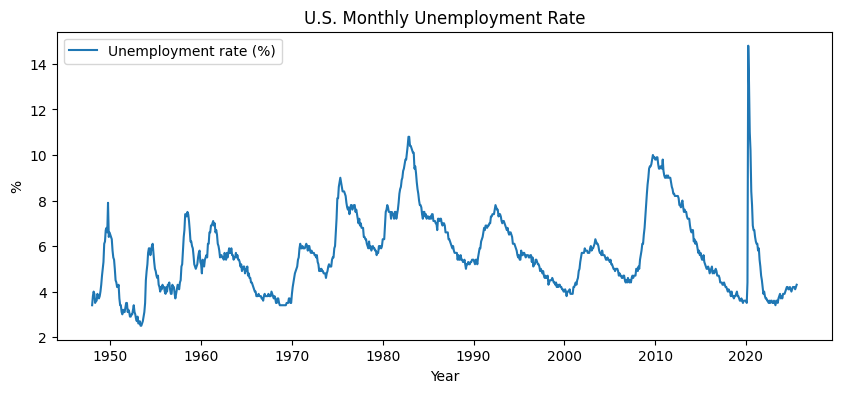

Train size: 745 Test size: 187
Mean: 5.661208053691276
Std: 1.5615976589128673
Min: 2.5
Max: 10.8


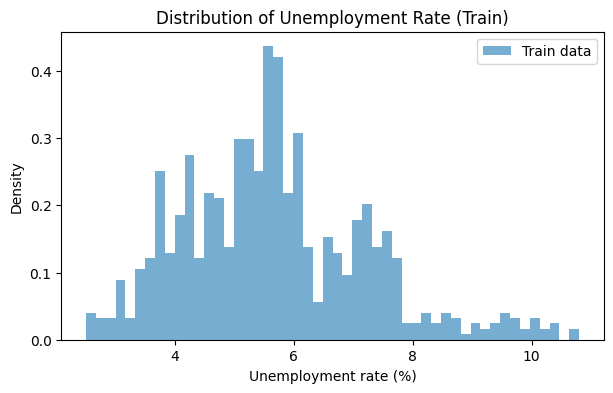

In [51]:
# Unemployment Rate GVI Setup Notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load dataset ---
file = "/Users/alya57/Desktop/fredgraph.csv"
df = pd.read_csv(file)

dates = pd.to_datetime(df["observation_date"])
y = df["UNRATE"].dropna().values  # unemployment rate (%)

print(f"Series length: {len(y)} observations")

# --- 2. Plot time series ---
plt.figure(figsize=(10,4))
plt.plot(dates, df["UNRATE"], label="Unemployment rate (%)")
plt.title("U.S. Monthly Unemployment Rate")
plt.xlabel("Year")
plt.ylabel("%")
plt.legend()
plt.show()



# --- 4. Train/test split (chronological) ---
split_idx = int(0.8 * len(y))
y_train, y_test = y[:split_idx], y[split_idx:]
print("Train size:", len(y_train), "Test size:", len(y_test))
print("Mean:", np.mean(y_train))
train_mean = np.mean(y_train)
print("Std:", np.std(y_train, ddof=1))
train_std =  np.std(y_train, ddof=1)
print("Min:", np.min(y_train))
print("Max:", np.max(y_train))

# --- 5. Histogram + KDE ---
plt.figure(figsize=(7,4))
plt.hist(y_train, bins=50, density=True, alpha=0.6, label="Train data")
plt.title("Distribution of Unemployment Rate (Train)")
plt.xlabel("Unemployment rate (%)")
plt.ylabel("Density")
plt.legend()
plt.show()

# --- Guidance for model choice ---
# From the histogram and summary stats:
# - If the distribution looks roughly symmetric and light-tailed -> Gaussian is fine.
# - If it shows heavy tails (spikes from recessions) -> Student-t with ν parameter.
# - If it's skewed right (unlikely for unemployment, but possible in other data) -> Lognormal or Gamma.
#
# Priors:
# - mu ~ Normal(0, 10^2) (wide, centered around plausible growth/unemployment levels)
# - log sigma^2 ~ Normal(0, 3^2) (covers wide uncertainty in variance)
# - for Student-t, log nu ~ Normal(log(10), 1^2) (moderate tails by default)


/var/folders/wl/l6v7zb5d5hv77sr6wky_w9km0000gn/T/ipykernel_9989/1833723587.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


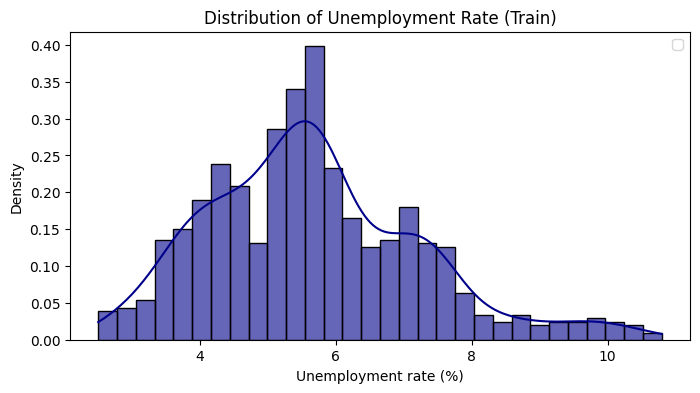

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

# Histogram with fewer bins
sns.histplot(y_train, bins=30, kde=True, color="darkblue", 
             edgecolor="black", alpha=0.6, stat="density")



plt.title("Distribution of Unemployment Rate (Train)")
plt.xlabel("Unemployment rate (%)")
plt.ylabel("Density")
plt.legend()
plt.show()


In [53]:
import numpy as np
import torch
import torch.nn as nn

# ------------------------------
# CONFIG
# ------------------------------
BATCH_SIZE = 32
MC_SAMPLES = 100
STEPS      = 2000
LR         = 1e-2
SEED       = 123

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Running deterministically with SEED={SEED}")

# ------------------------------
# PRIORS (based on training data)
# ------------------------------
train_mean = np.mean(y_train)
train_std  = np.std(y_train, ddof=1)
s2_hat     = train_std**2

prior_mean_mu     = float(train_mean)
prior_std_mu      = float(2.0 * train_std)     # wide Normal prior for mu
prior_mean_logsig = float(np.log(s2_hat))      # center prior at log variance
prior_std_logsig  = 1.5                        # wide prior for log σ²

# prior for phi (AR coefficient)
prior_mean_phi    = 0.0
prior_std_phi     = 0.5   # encourages |phi| < 1 but not too tight

# ------------------------------
# VARIATIONAL FAMILY: AR(1)
# ------------------------------
class VariationalGaussianAR1(nn.Module):
    def __init__(self, init_m=0.0, init_log_s=-2.0,
                 init_m_log_sigma2=0.0, init_log_s_log_sigma2=-2.0,
                 init_m_phi=0.5, init_log_s_phi=-2.0):
        super().__init__()
        # mu
        self.m_mu = nn.Parameter(torch.tensor(float(init_m)))
        self.log_s_mu = nn.Parameter(torch.tensor(float(init_log_s)))
        # log sigma^2
        self.m_logsig = nn.Parameter(torch.tensor(float(init_m_log_sigma2)))
        self.log_s_logsig = nn.Parameter(torch.tensor(float(init_log_s_log_sigma2)))
        # phi (AR coefficient)
        self.m_phi = nn.Parameter(torch.tensor(float(init_m_phi)))
        self.log_s_phi = nn.Parameter(torch.tensor(float(init_log_s_phi)))

    def sample_mu(self, num_samples=1):
        eps = torch.randn(num_samples, device=self.m_mu.device)
        return self.m_mu + torch.exp(self.log_s_mu) * eps

    def sample_sigma2(self, num_samples=1):
        eps = torch.randn(num_samples, device=self.m_logsig.device)
        log_sigma2 = self.m_logsig + torch.exp(self.log_s_logsig) * eps
        return torch.exp(log_sigma2)

    def sample_phi(self, num_samples=1):
        eps = torch.randn(num_samples, device=self.m_phi.device)
        raw_phi = self.m_phi + torch.exp(self.log_s_phi) * eps
        return torch.tanh(raw_phi)  # ensures φ ∈ (-1,1)

    def kl_divergence_mu(self, prior_mean=prior_mean_mu, prior_std=prior_std_mu):
        q_var = torch.exp(self.log_s_mu)**2
        tau2  = prior_std**2
        return 0.5 * ((q_var + (self.m_mu - prior_mean)**2)/tau2 
                      - 1.0 - torch.log(q_var/tau2 + 1e-12))

    def kl_divergence_sigma2(self, prior_mean=prior_mean_logsig, prior_std=prior_std_logsig):
        q_var = torch.exp(self.log_s_logsig)**2
        tau2  = prior_std**2
        return 0.5 * ((q_var + (self.m_logsig - prior_mean)**2)/tau2 
                      - 1.0 - torch.log(q_var/tau2 + 1e-12))

    def kl_divergence_phi(self, prior_mean=prior_mean_phi, prior_std=prior_std_phi):
        q_var = torch.exp(self.log_s_phi)**2
        tau2  = prior_std**2
        return 0.5 * ((q_var + (self.m_phi - prior_mean)**2)/tau2 
                      - 1.0 - torch.log(q_var/tau2 + 1e-12))




Running deterministically with SEED=123


In [54]:
def kld_loss_ar1(y, y_prev, mu, phi, sigma2):
    """
    Negative log-likelihood under AR(1):
    y_t ~ N(mu + phi * y_{t-1}, sigma^2)
    """
    mean_t = mu + phi * y_prev
    return -torch.distributions.Normal(mean_t, sigma2.sqrt()).log_prob(y).sum()


def beta_loss_ar1(y, y_prev, mu, phi, sigma2, beta):
    """
    β-loss for AR(1) Gaussian
    """
    mean_t = mu + phi * y_prev
    log_px = -0.5 * (y - mean_t)**2 / sigma2 - 0.5 * torch.log(2 * torch.pi * sigma2)
    px_beta = torch.exp(beta * log_px)

    likelihood_term = (1.0 / beta) * px_beta
    integral = 1.0 / ((2 * torch.pi)**(beta/2.0) * (1.0 + beta)**1.5 * (sigma2**(beta/2.0)))

    return -(likelihood_term.sum() - y.numel() * integral)


def gamma_loss_ar1(y, y_prev, mu, phi, sigma2, gamma):
    """
    γ-loss for AR(1) Gaussian (no σ² adjustment)
    """
    mean_t = mu + phi * y_prev
    log_px   = -0.5 * (y - mean_t)**2 / sigma2 - 0.5 * torch.log(2 * torch.pi * sigma2)
    px_gamma = torch.exp(gamma * log_px)

    integral = 1.0 / ((2 * torch.pi)**(gamma/2.0) * ((1.0 + gamma)**0.5) * (sigma2**(gamma/2.0)))
    like_sum = (1.0 / gamma) * px_gamma.sum() * (1.0 / (gamma + 1.0)) * (integral ** (-gamma/(gamma + 1.0)))

    return -(like_sum - y.numel() * integral)
def divergence_kl_ar1(q,
                      prior_mean_mu=prior_mean_mu, prior_std_mu=prior_std_mu,
                      prior_mean_logsig=prior_mean_logsig, prior_std_logsig=prior_std_logsig,
                      prior_mean_phi=prior_mean_phi, prior_std_phi=prior_std_phi):
    return (
        q.kl_divergence_mu(prior_mean=prior_mean_mu, prior_std=prior_std_mu) +
        q.kl_divergence_sigma2(prior_mean=prior_mean_logsig, prior_std=prior_std_logsig) +
        q.kl_divergence_phi(prior_mean=prior_mean_phi, prior_std=prior_std_phi)
    )



In [55]:
from torch.utils.data import TensorDataset, DataLoader

def make_ar1_minibatches(x_numpy, batch_size):
    x = torch.tensor(x_numpy, dtype=torch.float32)
    y = x[1:]
    y_prev = x[:-1]
    ds = TensorDataset(y, y_prev)
    return DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)


In [56]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

def train_gvi_ar1(x_numpy,
                  loss_type="nll",
                  divergence_type="kl",
                  beta=0.5, gamma=0.5,
                  steps=1000, lr=1e-3,
                  batch_size=64, mc_samples=10):
    
    loader = make_ar1_minibatches(x_numpy, batch_size=batch_size)
    N = len(x_numpy) - 1  # one less because we lose y0
    
    q = VariationalGaussianAR1()
    opt = optim.Adam(q.parameters(), lr=lr)

    # choose loss
    if loss_type == "nll":
        def loss_fn(y, y_prev, mu, phi, sigma2):
            return kld_loss_ar1(y, y_prev, mu, phi, sigma2)
    elif loss_type == "beta":
        def loss_fn(y, y_prev, mu, phi, sigma2):
            return beta_loss_ar1(y, y_prev, mu, phi, sigma2, beta)
    elif loss_type == "gamma":
        def loss_fn(y, y_prev, mu, phi, sigma2):
            return gamma_loss_ar1(y, y_prev, mu, phi, sigma2, gamma)

    step = 0
    while step < steps:
        for (yb, y_prev_b) in loader:
            opt.zero_grad()

            K = yb.shape[0]
            mc_vals = []
            for _ in range(mc_samples):
                mu_s     = q.sample_mu(1).squeeze(0)
                sigma2_s = q.sample_sigma2(1).squeeze(0)
                phi_s    = q.sample_phi(1).squeeze(0)
                ell_sum_batch = loss_fn(yb, y_prev_b, mu_s, phi_s, sigma2_s)
                ell_full = (N / K) * ell_sum_batch
                mc_vals.append(ell_full)

            data_term = torch.stack(mc_vals).mean()

            # divergence penalty
            reg_term = (
                q.kl_divergence_mu() +
                q.kl_divergence_sigma2() +
                q.kl_divergence_phi()
            )

            obj = data_term + reg_term
            obj.backward()
            opt.step()

            step += 1
            if step >= steps:
                break

    return q


In [57]:
def posterior_predictive_ar1(q, last_obs, num_samples=500):
    """
    One-step ahead predictive distribution for AR(1):
        y_t ~ N(mu + phi * y_{t-1}, sigma²)
    """
    with torch.no_grad():
        mus     = q.sample_mu(num_samples=num_samples).cpu().numpy()
        sigma2s = q.sample_sigma2(num_samples=num_samples).cpu().numpy()
        phis    = q.sample_phi(num_samples=num_samples).cpu().numpy()

    preds = []
    for mu, phi, sigma2 in zip(mus, phis, sigma2s):
        mean_pred = mu + phi * last_obs
        std_pred  = np.sqrt(sigma2)
        preds.append(np.random.normal(mean_pred, std_pred))

    return np.array(preds)


In [58]:
def posterior_predictive_ar1_multi(q, last_obs, horizon, num_samples=500):
    """
    Multi-step ahead predictive distribution for AR(1).
    
    Args:
        q: trained VariationalGaussianAR1
        last_obs: last training observation (scalar)
        horizon: number of steps to forecast (len of test set)
        num_samples: number of posterior draws
    
    Returns:
        forecasts: array of shape (num_samples, horizon)
    """
    with torch.no_grad():
        mus     = q.sample_mu(num_samples=num_samples).cpu().numpy()
        sigma2s = q.sample_sigma2(num_samples=num_samples).cpu().numpy()
        phis    = q.sample_phi(num_samples=num_samples).cpu().numpy()

    forecasts = np.zeros((num_samples, horizon))
    for s in range(num_samples):
        mu, phi, sigma2 = mus[s], phis[s], sigma2s[s]
        y_prev = last_obs
        for h in range(horizon):
            mean_pred = mu + phi * y_prev
            std_pred  = np.sqrt(sigma2)
            y_new     = np.random.normal(mean_pred, std_pred)
            forecasts[s, h] = y_new
            y_prev = y_new   # feed forward

    return forecasts


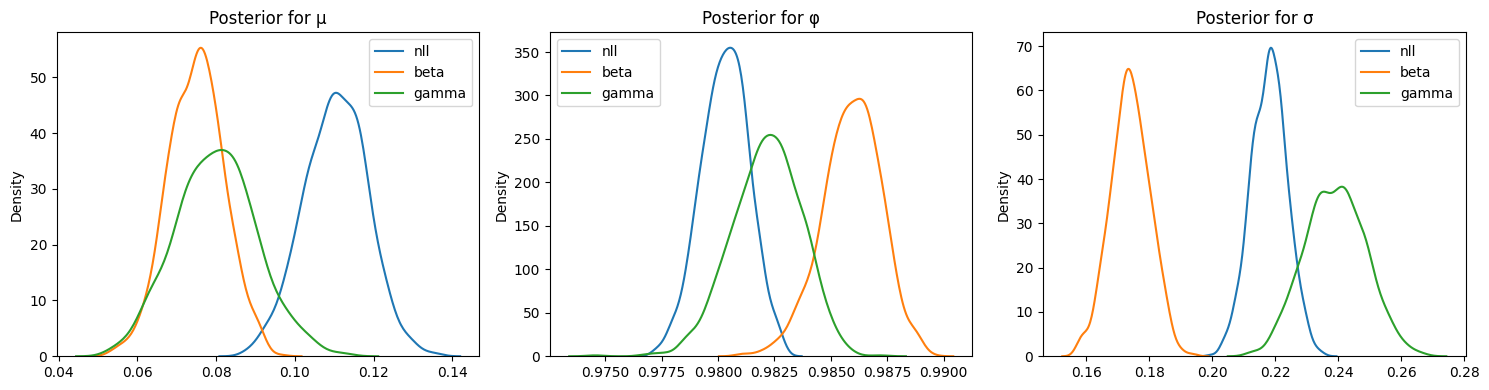

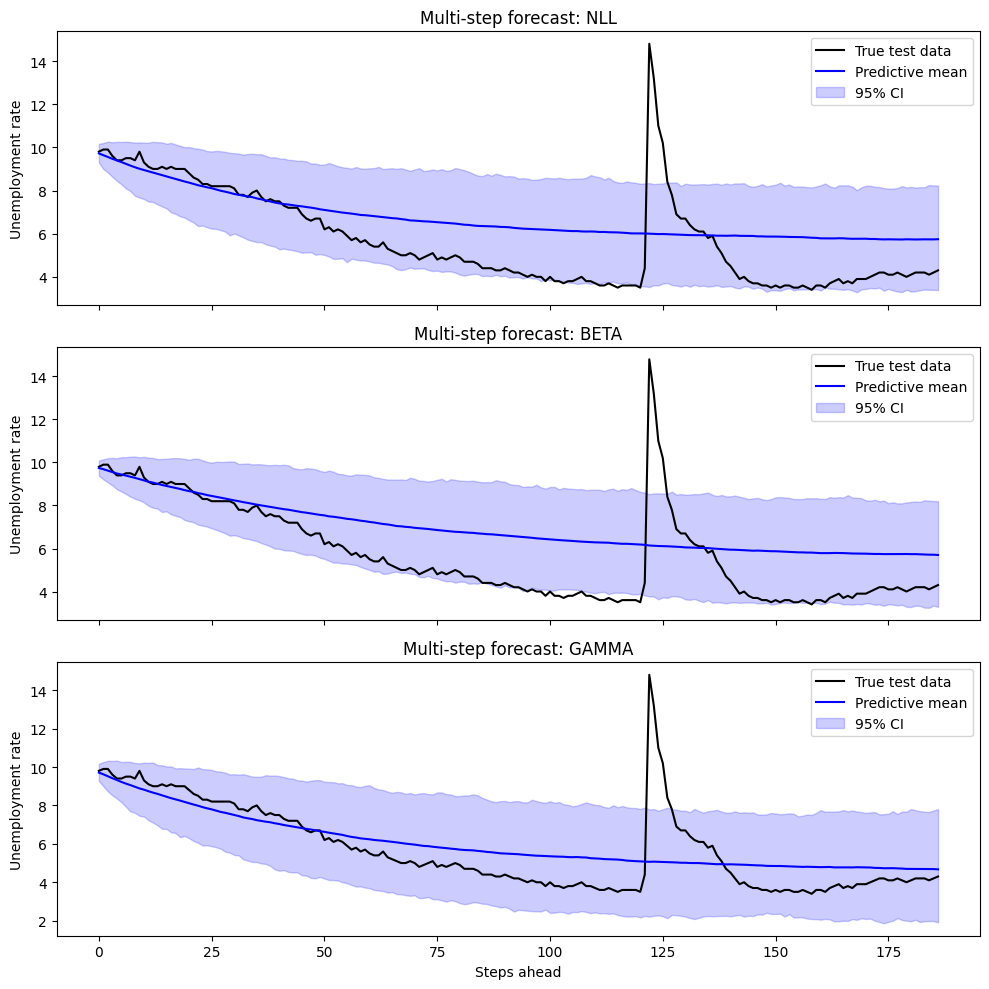

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# EXPERIMENT CONFIG
# ------------------------------
methods = [
    ("nll",   {"beta": None, "gamma": None}),
    ("beta",  {"beta": 0.7, "gamma": None}),
    ("gamma", {"beta": None, "gamma": 0.2}),
]

results = {}

# ------------------------------
# TRAIN VARIATIONAL MODELS
# ------------------------------
for method, params in methods:
    if method == "nll":
        qj = train_gvi_ar1(y_train, loss_type="nll", divergence_type="kl",
                           steps=2000, lr=1e-2, batch_size=32, mc_samples=50)
    elif method == "beta":
        qj = train_gvi_ar1(y_train, loss_type="beta", divergence_type="kl",
                           beta=params["beta"], steps=2000, lr=1e-2,
                           batch_size=32, mc_samples=50)
    elif method == "gamma":
        qj = train_gvi_ar1(y_train, loss_type="gamma", divergence_type="kl",
                           gamma=params["gamma"], steps=2000, lr=1e-2,
                           batch_size=32, mc_samples=50)
    else:
        raise RuntimeError("Unknown loss")

    results[method] = qj

# ------------------------------
# PLOT POSTERIOR PARAMETER DISTRIBUTIONS
# ------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, qj in results.items():
    with torch.no_grad():
        mu_samps  = qj.sample_mu(1000).cpu().numpy()
        phi_samps = qj.sample_phi(1000).cpu().numpy()
        sig_samps = np.sqrt(qj.sample_sigma2(1000).cpu().numpy())

    sns.kdeplot(mu_samps, ax=axes[0], label=method)
    sns.kdeplot(phi_samps, ax=axes[1], label=method)
    sns.kdeplot(sig_samps, ax=axes[2], label=method)

axes[0].set_title("Posterior for μ")
axes[1].set_title("Posterior for φ")
axes[2].set_title("Posterior for σ")
for ax in axes: ax.legend()
plt.tight_layout()
plt.show()

# ------------------------------
# PLOT MULTI-STEP FORECASTS VS TEST DATA
# ------------------------------
horizon = len(y_test)
fig, axes = plt.subplots(len(methods), 1, figsize=(10, 10), sharex=True)

for i, (method, qj) in enumerate(results.items()):
    forecasts = posterior_predictive_ar1_multi(qj, last_obs=y_train[-1], horizon=horizon, num_samples=1000)

    mean_pred = forecasts.mean(axis=0)
    low_pred  = np.percentile(forecasts, 2.5, axis=0)
    high_pred = np.percentile(forecasts, 97.5, axis=0)

    axes[i].plot(range(horizon), y_test, "k-", label="True test data")
    axes[i].plot(range(horizon), mean_pred, "b-", label="Predictive mean")
    axes[i].fill_between(range(horizon), low_pred, high_pred, color="blue", alpha=0.2, label="95% CI")
    axes[i].set_title(f"Multi-step forecast: {method.upper()}")
    axes[i].set_ylabel("Unemployment rate")
    axes[i].legend()

plt.xlabel("Steps ahead")
plt.tight_layout()
plt.show()

